# Python for Data Science
## Session 6
### Datasets – Pandas I 

---

## Outline

1. Pandas

2. Loading and exploring datasets 

3. Data cleaning and preprocessing with Pandas 

---

## Pandas I

**Pandas** is one of the most used libraries within the Data Science community. It provides a full set of tools to work with:
- 2D data via DataFrame class
    - SQL/Spreadsheet-like datasets (tabular data)
    - Arbitrary matrix data with row and column labels
    - Any type of dataset with observational / statistical data (no labels needed)
- 1D data via Series class
    - Time series data


## Pandas I

As one can see, from the type of datasets **Pandas** can handle, most of the use cases found in Data Science are covered, e.g. finance, health, biology, supply chain, or meteorology. Things **Pandas** do:

1. Handling missing data
2. Change DataFrame size, adding and removing columns and rows at will
3. Automatic data alignment of misaligned data
4. Group by operation
5. Data conversion
6. Advanced indexing
7. Data Merging and joining 
8. Reshaping data
9. Hierarchical indexing
10. Read/write support for CSV, Excel, databases, and fast HDF5 format.
11. Time series manipulation, frequency convertion, window moving statistics


## Pandas I

Let's create a few dataframes using different data structures and see how to start navigating them


In [4]:
## Let's create a simple DataFrame to work with
import pandas as pd
dataset = [
    {
        "name": "Amelie",
        "age": 35
    },
    {
        "name": "Edgar",
        "age": 32
    }
]
df = pd.DataFrame(dataset)
df

,name,age
0,Amelie,35
1,Edgar,32


In [5]:
# Using a slightly different data struture
data = {'Name': ['Amelie', 'Edgar', 'Carlos', 'Victor'],
        'Age': [24, 27, 22, 32],
        'Country': ['FR', 'FR', 'ES', 'GE']}
df = pd.DataFrame(data)
df

,Name,Age,Country
0,Amelie,24,FR
1,Edgar,27,FR
2,Carlos,22,ES
3,Victor,32,GE


In [6]:
# we can quickly visualize all the columns a dataframe contains by simply
df.columns

Index(['Name', 'Age', 'Country'], dtype='object')

In [7]:
# Another important thing we can do is to set up any specific index
# these act as row labels
df = pd.DataFrame(data, index=['A', 'B', 'C', 'D'])
df

,Name,Age,Country
A,Amelie,24,FR
B,Edgar,27,FR
C,Carlos,22,ES
D,Victor,32,GE


In [8]:
# Similar to lists and arrays, we can slice
df[:2]

,Name,Age,Country
A,Amelie,24,FR
B,Edgar,27,FR


In [9]:
# Similar to lists and arrays, we can also access elements making use of loc and iloc
df.loc['B':'D']

,Name,Age,Country
B,Edgar,27,FR
C,Carlos,22,ES
D,Victor,32,GE


In [10]:
# We can access elements using loc and iloc
df.iloc[1:]

,Name,Age,Country
B,Edgar,27,FR
C,Carlos,22,ES
D,Victor,32,GE


In [11]:
# We can also access element attributes by using at
df.at[0, 'Age']

KeyError: 0

In [ ]:
# if we wanted to do it with iloc, we would need to pass positions
df.iloc[0,1]

In [ ]:
# Important: to modify a specific value we can use at, loc and iloc
df.loc['B', 'Age'] = 123
df

In [ ]:
# we can also check what elements satisfy some criteria by column (attribute)
df['Age'] > 25

In [ ]:
# and show them
df[df['Age'] > 25]

In [ ]:
# or modify a simple attribute of those that satisfy certain condition
df.loc[df['Age'] > 25, 'Name'] = 'Unknown' # df.iloc[df['Age'] > 25, 0] = 'Unknown'
df

In [ ]:
# we can also, similar to the way we do with dicts, add new columns
df['Residency'] = [True, False, True, False]

In [ ]:
# or add new elements
df.loc[6] = ['Jordi', 23, 'ES', False]
df.loc[9] = ['Anna', 19, 'ES', False]
df

In [ ]:
# There are other methods one can also call
df.head(2)

In [ ]:
# There are other methods one can also call
df.tail(2)

In [ ]:
df.shape # to get the dataframe shape

In [ ]:
df.dtypes

In [ ]:
df['Age'].astype('float')

In [ ]:
# Same as numpy, we can find the unique method
df['Country'].unique()

## Pandas I

Among the different methods two important ones are **info** and **describe**:

In [ ]:
df.info()

In [ ]:
df.describe()

## Pandas I

And how do we know about missing elements and handle them?

In [ ]:
# What about missing values? Missing values are usually represented as NaN (Not a Number)
import numpy as np
data = {'Name': ['Amelie', 'Edgar', 'Carlos', 'Victor'],
        'Age': [24, 27, 22, 32],
        'Country': ['FR', np.nan, 'ES', 'GE']}
df = pd.DataFrame(data)
df

In [ ]:
# we can simply know which ones present missing values by using isna or isnull
df.isna() # at the whole dataframe level

In [ ]:
# and at the column level
df['Country'].isnull() # same as .isna()

In [ ]:
# Simple way of filling these ones is achieved by calling fillna
df.fillna('RE')

In [ ]:
# There's also possible thing you can do, use the mode (most common value)
#df['Country'].mode()
df.fillna(df['Country'].mode()[0])

In [ ]:
# IMPORTANT: if we check again the dataframe, we will see that the dataframe keeps having NaNs
# This is because the intented behaviour is usually to keep the DataFrame immutable
# If you want to actually modify you can pass ot fillna, inplace=True
df

In [ ]:
# A more drastic operation is to drop any column or row with missing values using
# here, we will modify the original dataframe and drop the rows and cols with nans
df.at[0, 'Age'] = np.nan
df

In [ ]:
df.dropna()

## Pandas I

One of the handy tools you have in **Pandas** is **groupby**. It allows you to group by any unique attributes within a column and get statistics:
- count
- mean
- sum
- min and max
- multiple aggregations
- group using multiple columns

In [ ]:
data = {
    'Name': ['Amelie', 'Edgar', 'Carlos', 'Victor', 'Sofia', 'Jin', 
             'Marta', 'Ali', 'Emily', 'Ravi', 'Chen', 'Fatima', 'Saham'],
    'Age': [24, 27, 22, 32, 29, 31, 28, 26, 23, 34, 25, 30, 26],
    'Country': ['FR', 'US', 'ES', 'GE', 'PT', 'KR',
                'ES', 'AE', 'US', 'IN', 'CN', 'AE', 'AE'],
    'Salary': [70000, 110000, 65000, 82000, 48000, 39000, 45000,
            90000, 97000, 31000, 49000, 85000, 80000]   
}

df = pd.DataFrame(data)
df

In [ ]:
# let's count how many we have per country
df.groupby('Country').count()

In [ ]:
df.groupby('Country')['Age'].mean() # now let's know the average age per country

In [ ]:
df.groupby('Country')['Salary'].sum() # total sum of their salaries

In [ ]:
# Multiple Aggregations
df.groupby('Country').agg({'Salary': ['min', 'max'], 'Age': 'mean'})

In [ ]:
# grouping using more than one column
df.groupby(['Country', 'Age'])['Salary'].count()

## Pandas I

Let's load *Netflix* titles and do some exercices

In [ ]:
# Download from Moodle the zip file containing the netflix dataset
path = 'session_6/netflix_titles.csv'

df = pd.read_csv(path)

In [ ]:
df.columns

## Pandas I
Let's do the following exercices:

1. Count Missing Values in Each Column

2. Fill Missing 'country' Values with "Unknown"

3. Filter for TV Shows Only

4. Count the Number of Entries per Rating

5. Add a Column Showing Content Age (how many years since it came out)


## Pandas I

Let's now load the *Titanic* dataset and practice a little bit more:

1. Count the Missing Values in Each Column

2. Fill Missing 'Age' Values with the Mean Age

3. Fill Missing 'Embarked' Values with the Mode (Most Common Value)

4. Filter and Display Passengers Who Paid a Fare Above the Average Fare

5. Add a New Column Indicating Family Size. Create a new column 'FamilySize' as the sum of 'SibSp' (siblings/spouses) and 'Parch' (parents/children)

In [ ]:
path = 'session_6/train_and_test2.csv'

df = pd.read_csv(path)

NameError: name 'pd' is not defined

## Pandas I

Home exercises for Netflix:

1. Is there any missing rating?
2. How many films in 2021 correspond to your country?
3. What's the number of movies in 2020 with full information?
4. Give me the year with more titles,
5. and what has been the average in terms of releases from 2010. 

And for Titanic:

1. Calculate Gender-Based Survival Percentage

2. Calculate Survival Percentage Grouped by Gender and Class

# **Exercise 1: Is there any missing rating?**


In [32]:
import pandas as pd

path = r"C:\Users\enric\OneDrive - Universitat Ramón Llull\ESADE\Term 1\Python for Data Science\Assigment 6\netflix_titles.csv.zip"

df = pd.read_csv(path)

# Count missing ratings
missing_ratings = df['rating'].isnull().sum()
print(f"The number of the missing ratings is the following: {missing_ratings}")


The number of the missing ratings is the following: 4


# **Exercise 2: How many fils correspond to your country?**


In [20]:
movies_2021_spain = df[(df['type'] == 'Movie') & (df['release_year'] == 2021) & (df['country'].str.contains('Spain', na=False))]

num_movies_2021_spain = movies_2021_spain.shape[0]
print(f"The number of movies from Spain released in 2021 are the following: {num_movies_2021_spain}")

The number of movies from Spain released in 2021 are the following: 6


# **Exercise 3: What is the number of films in 2020 with full information?**


In [22]:
movies_2020 = df[(df['type'] == 'Movie') & (df['release_year'] == 2020)]

movies_2020_full_info = movies_2020.dropna()

num_movies_2020_full_info = movies_2020_full_info.shape[0]
print(f"The number of movies in 2020 with full information is the following: {num_movies_2020_full_info}")

The number of movies in 2020 with full information is the following: 409


# **Exercise 4: Give me the years with more titles?**


In [24]:
titles_per_year = df.groupby('release_year').size()

max_titles_year = titles_per_year.idxmax()
max_titles_count = titles_per_year.max()
print(f"The year with the most titles is {max_titles_year} with a maxiumum of {max_titles_count} titles.")

The year with the most titles is 2018 with a maxiumum of 1147 titles.


# **Exercise 5: Average terms of releases in 2020?**


In [27]:
df_2010_onwards = df[df['release_year'] >= 2010]

titles_per_year_2010_onwards = df_2010_onwards.groupby('release_year').size()

average_releases_per_year = round(titles_per_year_2010_onwards.mean(),2)
print(f"The average number of releases per year since 2010 is approximately {average_releases_per_year:.2f}.")

The average number of releases per year since 2010 is approximately 622.67.


# **Exercise Titanic 1:**


In [31]:

df = pd.read_csv('train_and_test2.csv')

# Map numeric gender values to readable categories
df['Sex'] = df['Sex'].map({0: 'Male', 1: 'Female'})

# number of gender occurrences
gender_counts = df['Sex'].value_counts()

#  survival occurrences
gender_survival_counts = df[df['2urvived'] == 1]['Sex'].value_counts()

# C survival percentages
gender_survival_percentage = (gender_survival_counts / gender_counts) * 100

print("The Gender-Based Survival Percentage is the following:")
print(gender_survival_percentage)


The Gender-Based Survival Percentage is the following:
Sex
Female    50.000000
Male      12.930012
Name: count, dtype: float64


# **Exercise Titanic 2:**


Updated Columns: Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', '2urvived'],
      dtype='object')
Unique values in 'Sex': ['Male' 'Female']
Survival Percentage Grouped by Gender and Class:
Sex     Pclass
Female  1         63.194444
        2         66.037736
        3         33.333333
Male    1         25.139665
        2          9.941520
        3          9.533469
Name: 2urvived, dtype: float64


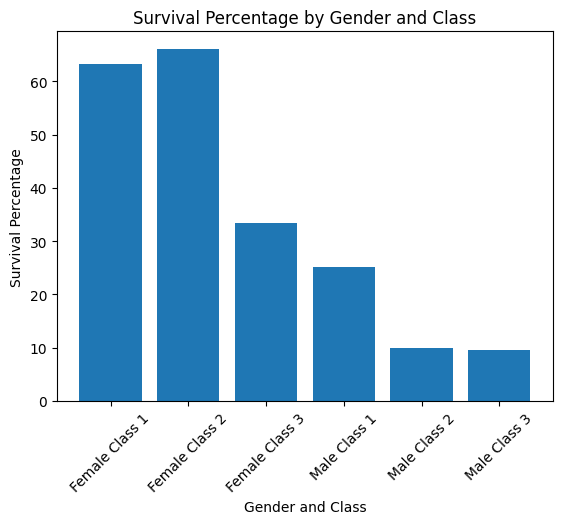

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train_and_test2.csv')

# Here we inspect and drop irrelevant columns
df = df.drop(columns=[col for col in df.columns if 'zero' in col.lower()])  
print("Updated Columns:", df.columns)

# Here we m ap the '"Sex" column to readable values
if df['Sex'].dtype in ['int64', 'float64']:  # Check if numeric
    df['Sex'] = df['Sex'].map({0: 'Male', 1: 'Female'})

print("Unique values in 'Sex':", df['Sex'].unique())

# Now we Group by 'Sex' and 'Pclass' and calculate survival rate
survival_by_gender_class = df.groupby(['Sex', 'Pclass'])['2urvived'].mean() * 100

print("Survival Percentage Grouped by Gender and Class:")
print(survival_by_gender_class)

#EXTRA: Here i visualized the survival percentages
survival_by_gender_class = survival_by_gender_class.reset_index()

#I aim to plot a bar chart
plt.bar(
    survival_by_gender_class['Sex'] + " Class " + survival_by_gender_class['Pclass'].astype(str),
    survival_by_gender_class['2urvived']
)
plt.xlabel("Gender and Class")
plt.ylabel("Survival Percentage")
plt.title("Survival Percentage by Gender and Class")
plt.xticks(rotation=45)
plt.show()








